#AGN FINAL PROJECT
## Sona Davis


TASK 1:
The first project task is to extract top 10,000 galaxies with narrow emission lines with redshift z<0.35 from the SDSS database (e.g., DR17 or DR18 –http://www.sdss.org/) using the SQL search and produce BPT diagram.

task a) Obtain the following line fluxes[O III] l5007, Hb, [N II] l6583, Ha, [S II] ll6716, 6731, [O I] l6300, and equivalent width of Ha from the SDSS spectral databases (tips: when selecting galaxies define as one of the criteria that you only need narrow emission line; find a way to calculate line fluxes using only data available in SDSS tables). For the division line use the theoretical curves obtained by Kewley et al. (2001) and empirical curves from Kauffman et al. (2003). Make plots for [O III] l5007/Hb vs. [N II] l6583/Ha, denoting with different marks/colors different object

SQL query to obtain the galaxies from SDSS database

SELECT TOP 10000

--count(*)

s.plate, s.mjd, s.fiberid, s.z, s.ra, s.dec,

g.h_alpha_flux, g.h_beta_flux, g.oiii_5007_flux, g.nii_6584_flux, g.oi_6300_flux,

g.sii_6717_flux, g.sii_6731_flux,

g.h_alpha_eqw

FROM SpecObj AS s

JOIN GalSpecLine AS g ON s.specobjid = g.specobjid

WHERE

g.h_alpha_eqw < 0 -- ensure emission in H_alpha

AND g.h_beta_eqw < 0 -- ensure emission in H_beta

AND g.oiii_5007_eqw < 0 -- ensure emission in [OIII]5007

AND g.nii_6584_eqw < 0

AND g.oi_6300_eqw < 0

AND g.sii_6717_eqw < 0

AND g.sii_6731_eqw <0

AND g.h_beta_flux > 0

AND g.h_alpha_flux > 0

AND g.oiii_5007_flux > 0

AND g.nii_6584_flux > 0

AND g.oi_6300_flux > 0

AND g.sii_6717_flux > 0

AND g.sii_6731_flux > 0

AND SQRT(8*LOG(2)) * g.sigma_balmer < 500 -- FWHM = sigma * sqrt(8ln(2)) for narrow emission lines

AND s.class = "GALAXY"

AND s.z < 0.35

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Skyserver_Radial2_19_2026 5_18_22 PM
#data = pd.read_csv('Skyserver_Radial2_19_2026 5_18_22 PM.csv',skiprows=1) # File retrieved from SQL search of SDSS survey
data = pd.read_csv('/content/t1.csv',skiprows=1)

In [3]:
data.head()

,plate,mjd,fiberid,z,ra,dec,h_alpha_flux,h_beta_flux,oiii_5007_flux,nii_6584_flux,oi_6300_flux,sii_6717_flux,sii_6731_flux,h_alpha_eqw
0,266,51630,6,0.052654,146.63167,-0.988278,127.30580,38.33226,35.46671,25.78963,6.269853,30.26996,25.72297,-21.187690
1,266,51630,223,0.145823,145.60120,-0.001389,850.13950,109.63070,130.83390,427.15960,66.433190,202.71810,165.03950,-70.000720
2,266,51630,341,0.097905,145.34123,0.547307,174.81240,33.71523,18.59770,72.38217,8.882089,36.02143,19.18493,-11.627980
3,266,51630,436,0.036699,145.72946,0.126896,225.36870,49.74669,15.15882,89.19385,6.441563,46.17053,32.38400,-12.713860
4,266,51630,632,0.092846,147.32681,0.245493,98.09557,27.12378,17.24143,44.43774,8.424724,20.84057,15.10460,-9.581162


In [4]:
data['y_values'] = np.log10(data['oiii_5007_flux']/data['h_beta_flux'])
data['x_values'] = np.log10(data['nii_6584_flux']/data['h_alpha_flux'])

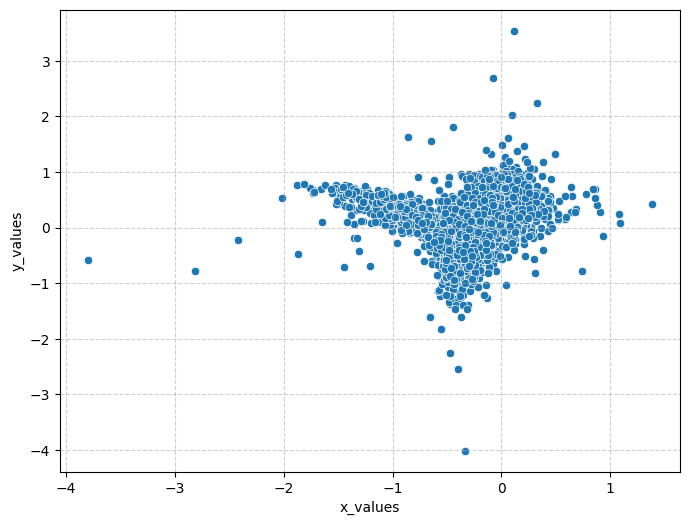

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=data,x='x_values',y='y_values')
plt.grid(True,linestyle='--',alpha=0.6)

In [6]:
x_vals_e = np.linspace(-2, 0.34, 10000)
x_vals_a = np.linspace(-2, 0, 10000)

def kewley(logx):
    return np.where(logx <= 0.34, 0.61 / (logx - 0.47) + 1.19, -10)

def kauffmann(logx):
    return np.where(logx <= 0, 0.61 / (logx - 0.05) + 1.3, -10)

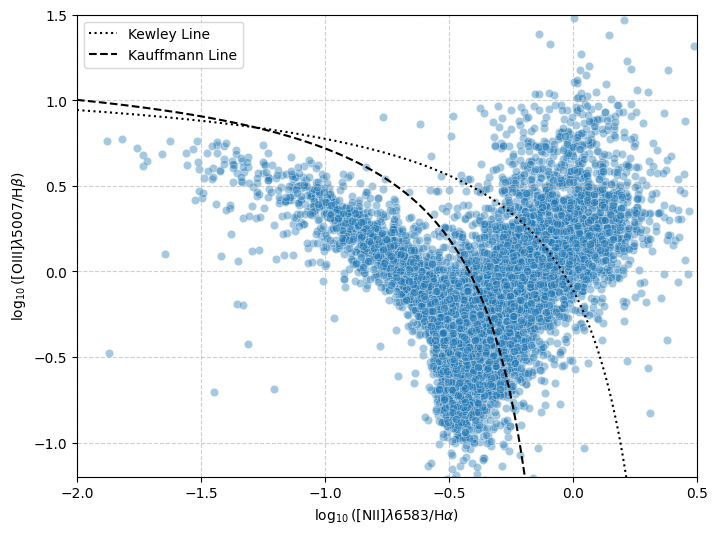

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=data,x='x_values',y='y_values',alpha=0.4)
plt.plot(x_vals_e,kewley(x_vals_e),':',color='black',label='Kewley Line')
plt.plot(x_vals_a,kauffmann(x_vals_a),'--',color='black',label='Kauffmann Line')
plt.xlabel(r'$\log_{10}([\mathrm{NII}]\lambda6583 / \mathrm{H}\alpha)$')
plt.ylabel(r'$\log_{10}([\mathrm{OIII}]\lambda5007 / \mathrm{H}\beta)$')
plt.xlim(-2,0.5)
plt.ylim(-1.2,1.5)
plt.legend()
plt.grid(True,linestyle='--',alpha=0.6)

In [ ]:
data['Type'] = 'Unclassified'
for i in range(10000):
    if np.log10(data['oiii_5007_flux'][i]/data['h_beta_flux'][i]) > kewley(np.log10(data['nii_6584_flux'][i]/data['h_alpha_flux'][i])):
        data['Type'][i] = 'AGN'
    elif np.log10(data['oiii_5007_flux'][i]/data['h_beta_flux'][i]) > kauffmann(np.log10(data['nii_6584_flux'][i]/data['h_alpha_flux'][i])):
        data['Type'][i] = 'Composites'
    else:
        data['Type'][i] = 'Galaxies'

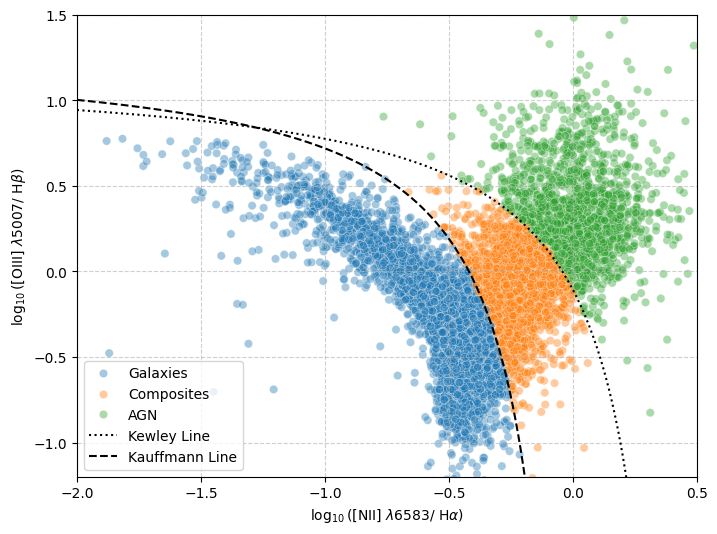

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=data,x='x_values',y='y_values',hue='Type',alpha=0.4)
plt.plot(x_vals_e,kewley(x_vals_e),':',color='black',label='Kewley Line')
plt.plot(x_vals_a,kauffmann(x_vals_a),'--',color='black',label='Kauffmann Line')
plt.xlim(-2,0.5)
plt.ylim(-1.2,1.5)
plt.xlabel(r'$\log_{10}([\mathrm{NII}] \ \lambda6583 /  \ \mathrm{H}\alpha)$')
plt.ylabel(r'$\log_{10}([\mathrm{OIII}] \ \lambda5007 / \ \mathrm{H}\beta)$')
plt.legend()
plt.grid(True,linestyle='--',alpha=0.6)
plt.savefig('BPT.png', bbox_inches='tight', pad_inches=0, transparent=True)

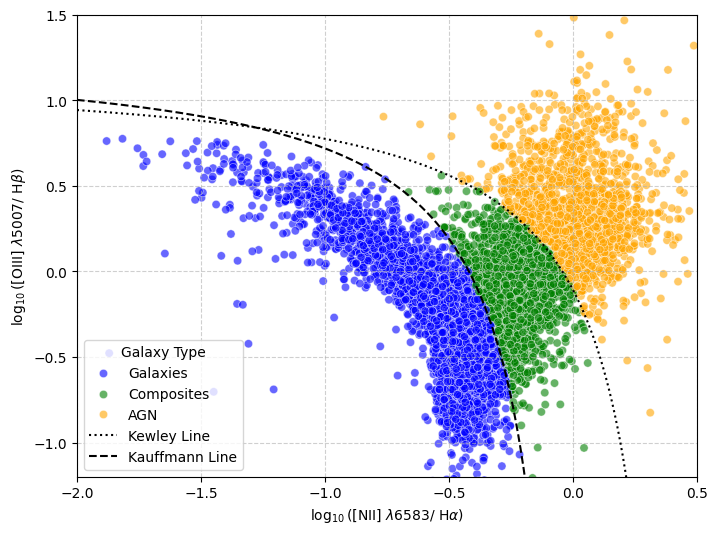

In [10]:
# Define a custom color palette
custom_palette = {
    'Galaxies': 'blue',   # star-forming galaxies
    'Composites': 'green',       # composite galaxies
    'AGN': 'orange'            # active galactic nuclei
}

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x='x_values',
    y='y_values',
    hue='Type',          # column defining classes
    palette=custom_palette,
    alpha=0.6
)

# Plot Kewley and Kauffmann lines
plt.plot(x_vals_e, kewley(x_vals_e), ':', color='black', label='Kewley Line')
plt.plot(x_vals_a, kauffmann(x_vals_a), '--', color='black', label='Kauffmann Line')

plt.xlim(-2,0.5)
plt.ylim(-1.2,1.5)

plt.xlabel(r'$\log_{10}([\mathrm{NII}] \ \lambda6583 /  \ \mathrm{H}\alpha)$')
plt.ylabel(r'$\log_{10}([\mathrm{OIII}] \ \lambda5007 / \ \mathrm{H}\beta)$')

plt.legend(title='Galaxy Type')
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('BPTc.png', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()


b)

In [11]:
data['y2_values'] = np.log10(-data['h_alpha_eqw'])

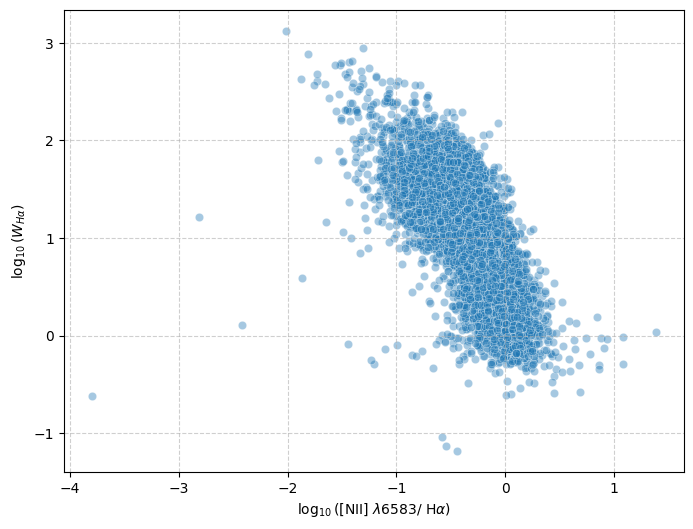

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=data,x='x_values',y='y2_values',alpha=0.4)
plt.xlabel(r'$\log_{10}([\mathrm{NII}] \ \lambda6583 /  \ \mathrm{H}\alpha)$')
plt.ylabel(r'$\log_{10}(W_{H\alpha})$')
#plt.legend()
plt.grid(True,linestyle='--',alpha=0.6)

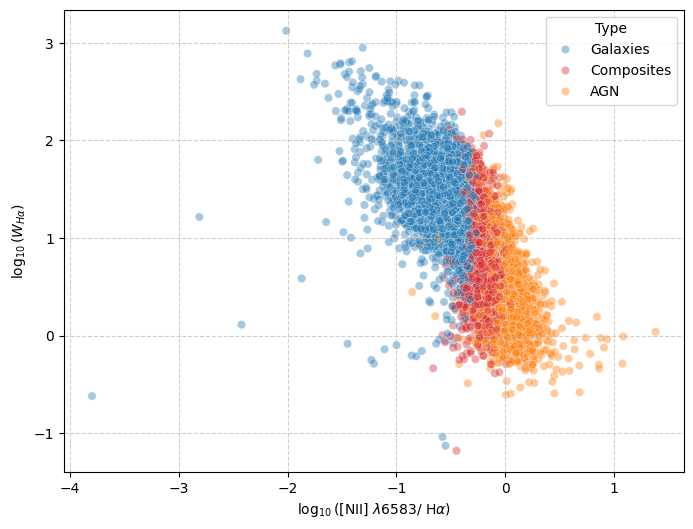

In [13]:
palette_dict = {
    'Galaxies': '#1f77b4',
    'Composites': '#d62728',
    'AGN': '#ff7f0e'
}
plt.figure(figsize=(8,6))
sns.scatterplot(data=data,x='x_values',y='y2_values',hue='Type' ,alpha=0.4,palette=palette_dict)
plt.xlabel(r'$\log_{10}([\mathrm{NII}] \ \lambda6583 /  \ \mathrm{H}\alpha)$')
plt.ylabel(r'$\log_{10}(W_{H\alpha})$')
#plt.legend()
plt.grid(True,linestyle='--',alpha=0.6)
#plt.savefig('WHAN_BPT.png', bbox_inches='tight', pad_inches=0, transparent=True)

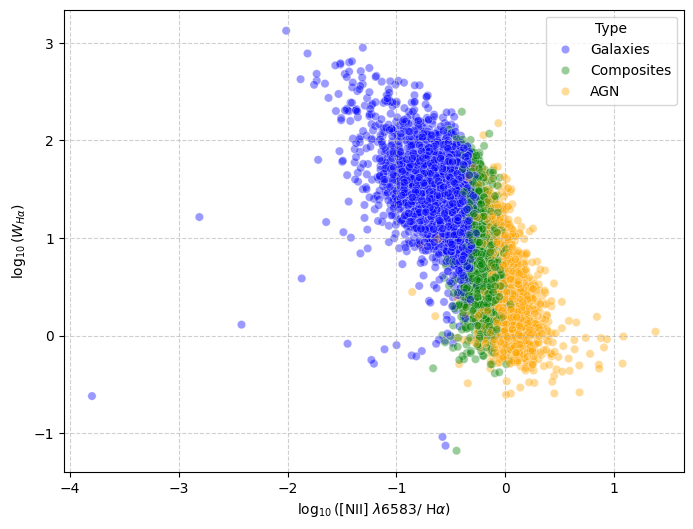

In [14]:
palette_dict = {
    'Galaxies': 'blue',
    'Composites': 'green',
    'AGN': 'orange'
}
plt.figure(figsize=(8,6))
sns.scatterplot(data=data,x='x_values',y='y2_values',hue='Type' ,alpha=0.4,palette=palette_dict)
plt.xlabel(r'$\log_{10}([\mathrm{NII}] \ \lambda6583 /  \ \mathrm{H}\alpha)$')
plt.ylabel(r'$\log_{10}(W_{H\alpha})$')
#plt.legend()
plt.grid(True,linestyle='--',alpha=0.6)
plt.savefig('WHAN_BPT.png', bbox_inches='tight', pad_inches=0, transparent=True)

In [15]:
data['Type_WHAN'] = 'Unclassified'
for i in range(10000):
    y= -data['h_alpha_eqw'][i]
    logx = data['x_values'][i]
    if (logx < -0.4) and (y > 3 ):
        data['Type_WHAN'][i] = 'Star-Forming'
    elif (logx > -0.4) and (y > 6 ):
        data['Type_WHAN'][i] = 'Seyfert'
    elif (logx > -0.4) and (y > 3 ):
        data['Type_WHAN'][i] = 'Weak AGN'
    else:
        data['Type_WHAN'][i] = 'RG'

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['Type_WHAN'][i] = 'Star-Forming'
/tmp/ipython-input-1266683508.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Type_WHAN'][i] = 'Star-Forming'
/tmp/ipython-input-1266683508.py:8: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is whe

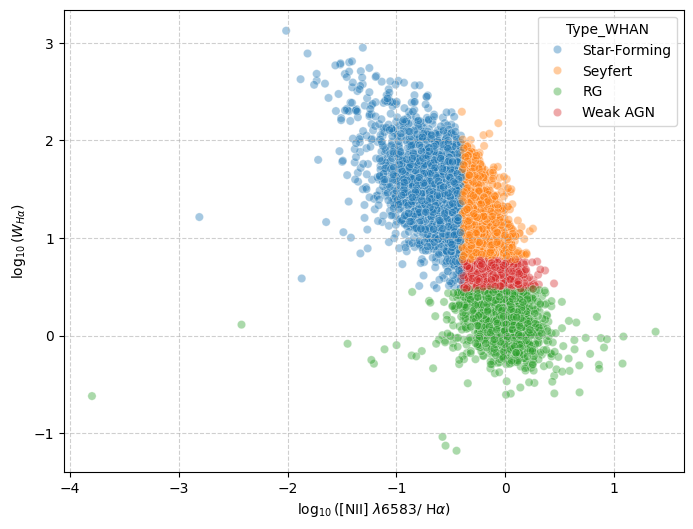

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=data,x='x_values',y='y2_values',hue='Type_WHAN',alpha=0.4)
plt.xlabel(r'$\log_{10}([\mathrm{NII}] \ \lambda6583 /  \ \mathrm{H}\alpha)$')
plt.ylabel(r'$\log_{10}(W_{H\alpha})$')
#plt.legend()
plt.grid(True,linestyle='--',alpha=0.6)

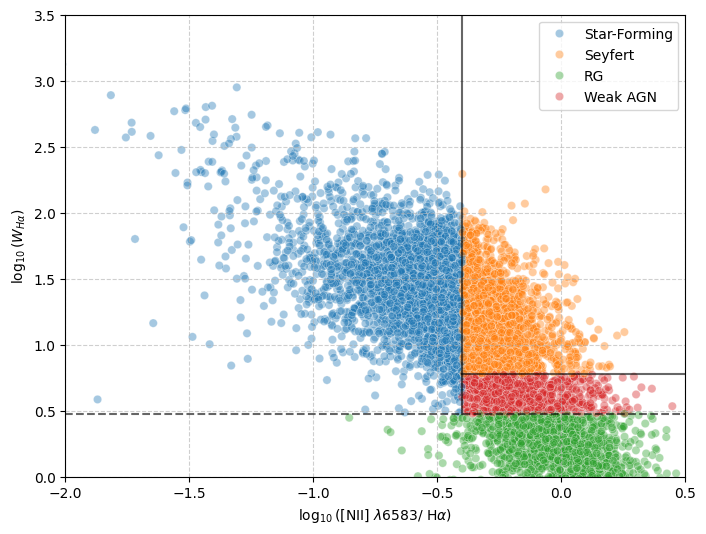

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=data,x='x_values',y='y2_values',hue='Type_WHAN',alpha=0.4)
plt.xlim(-2,0.5)
plt.ylim(0,3.5)
plt.plot([-2,2],[np.log10(3),np.log10(3)],'--',color='black',alpha=0.6) #LOW
plt.plot([-0.4,2],[np.log10(6),np.log10(6)],'-',color='black',alpha=0.6) #MID
plt.plot([-0.4,-0.4],[np.log10(3),3.5],'-',color='black',alpha=0.6) #VERTICAL

plt.xlabel(r'$\log_{10}([\mathrm{NII}] \ \lambda6583 /  \ \mathrm{H}\alpha)$')
plt.ylabel(r'$\log_{10}(W_{H\alpha})$')
plt.legend()
plt.grid(True,linestyle='--',alpha=0.6)
#plt.savefig('WHAN.png', bbox_inches='tight', pad_inches=0, transparent=True)

In [18]:
print(data['Type_WHAN'].unique())


['Star-Forming' 'Seyfert' 'RG' 'Weak AGN']


In [19]:
custom_palette = {
    'Star-Forming': 'royalblue',
    'Weak AGN': 'orange',
    'Seyfert': 'red',
    'RG': 'gray'
}


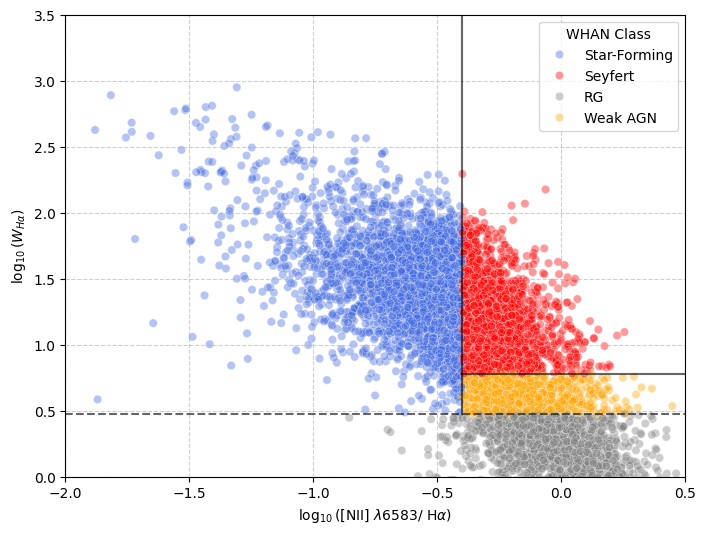

<Figure size 640x480 with 0 Axes>

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x='x_values',
    y='y2_values',
    hue='Type_WHAN',
    palette=custom_palette,   # <-- ADD THIS
    alpha=0.4
)

plt.xlim(-2,0.5)
plt.ylim(0,3.5)

plt.plot([-2,2],[np.log10(3),np.log10(3)],'--',color='black',alpha=0.6)
plt.plot([-0.4,2],[np.log10(6),np.log10(6)],'-',color='black',alpha=0.6)
plt.plot([-0.4,-0.4],[np.log10(3),3.5],'-',color='black',alpha=0.6)

plt.xlabel(r'$\log_{10}([\mathrm{NII}] \ \lambda6583 /  \ \mathrm{H}\alpha)$')
plt.ylabel(r'$\log_{10}(W_{H\alpha})$')

plt.legend(title='WHAN Class')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()
plt.savefig('WHANc.png')


In [21]:
count=0
count_w=0
for i in range(10000):
    if data['Type'][i] == 'AGN':
        count += 1
    if data['Type_WHAN'][i] == 'Seyfert':
        count_w += 1
BPT_N = count
WHAN_N = count_w
print(f"Number of AGN's in group using BPT diagram:                {count} ({round(count/100,1)}%)")
print(f"Number of Seyfert Galaxies in group using WHAN diagram:    {count_w} ({round(count_w/100,1)}%)")

Number of AGN's in group using BPT diagram:                1657 (16.6%)
Number of Seyfert Galaxies in group using WHAN diagram:    2618 (26.2%)


In [22]:
count=0
count_w=0
for i in range(10000):
    if data['Type'][i] == 'AGN':
        count += 1
    if data['Type_WHAN'][i] == 'Seyfert':
        count_w += 1
BPT_N = count
WHAN_N = count_w
print(f"Number of AGN's in group using BPT diagram:                {count} ({round(count/100,1)}%)")
print(f"Number of Seyfert Galaxies in group using WHAN diagram:    {count_w} ({round(count_w/100,1)}%)")

Number of AGN's in group using BPT diagram:                1657 (16.6%)
Number of Seyfert Galaxies in group using WHAN diagram:    2618 (26.2%)


In [23]:
count=0
for i in range(10000):
    if (data['Type'][i] == 'AGN') and (data['Type_WHAN'][i] == 'Seyfert'):
        count+=1
print(count)

302


TAsk 2


In [30]:
names = [] # For the Cross-match ID, a txt file is needed including name, Ra and Dec:
ra = []
dec = []
for i in range(10000):
    #if (data['Type'][i] == 'AGN') or (data['Type_WHAN'][i] == 'Seyfert'):
    names.append(f'A{i}')
    ra.append(data['ra'][i])
    dec.append(data['dec'][i])

In [25]:
export = {'name':names,'ra':ra,'dec':dec}
df = pd.DataFrame(export)

In [26]:
data['name'] = names

In [27]:
df.head()

,name,ra,dec
0,A0,146.63167,-0.988278
1,A1,145.60120,-0.001389
2,A2,145.34123,0.547307
3,A3,145.72946,0.126896
4,A4,147.32681,0.245493


In [28]:
df.to_csv('crossmatchID.txt',sep=' ', index=False)

In [ ]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.1 MB/s eta 0:00:00


In [ ]:
from astroquery.sdss import SDSS
sdss = SDSS()


-  SELECT W.w1mpro AS w1, W.w2mpro AS w2,
-  W.w3mpro AS w3
-  FROM #upload u
- JOIN #x x ON x.up_id = u.up_id
- JOIN PhotoTag p ON p.objID = x.objID
- JOIN wise_xmatch AS Y ON p.objID = Y.sdss_objid
- JOIN wise_allsky AS W ON Y.wise_cntr = W.cntr


wise_query = """SELECT
s.plate, s.mjd, s.fiberid, s.z as redshift, g.subclass,
w.w1mpro as w1, w.w2mpro as w2, w.w3mpro as w3, w.w1flux, w.w2flux, w.w3flux
from SpecObjAll as s
join GalSpecInfo as g on s.specobjid = g.specobjid
join GalSpecLine as l on s.specobjid = l.specobjid
join wise_xmatch as x on s.bestobjid = x.sdss_objid
join wise_allsky as w on x.wise_cntr = w.cntr
where (s.class = "QSO" or s.class = "GALAXY")
and s.z < 0.35
and (l.sigma_balmer * 2.355) < 500
and x.match_dist <= 3
and w.w1snr > 5
and w.w2snr > 5
and w.w3snr > 5
and w.w1flux/w.w1sigflux > 5
and w.w2flux/w.w2sigflux > 5
and w.w3flux/w.w3sigflux > 5"""

wdf = sdss.query_sql(wise_query, timeout=500).to_pandas()

In [ ]:
wdf=pd.read_csv('/content/sample_data/Skyserver_SQL2_19_2026 6_15_04 PM wise.csv',skiprows=1)

In [31]:
#wdf.head()

In [ ]:
len(wdf)

10000

In [ ]:
wdf.reset_index(drop=True, inplace=True)

In [ ]:
wdf['W1-W2 [mag]'] = wdf['w1'] - wdf['w2']
wdf['W2-W3 [mag]'] = wdf['w2'] - wdf['w3']

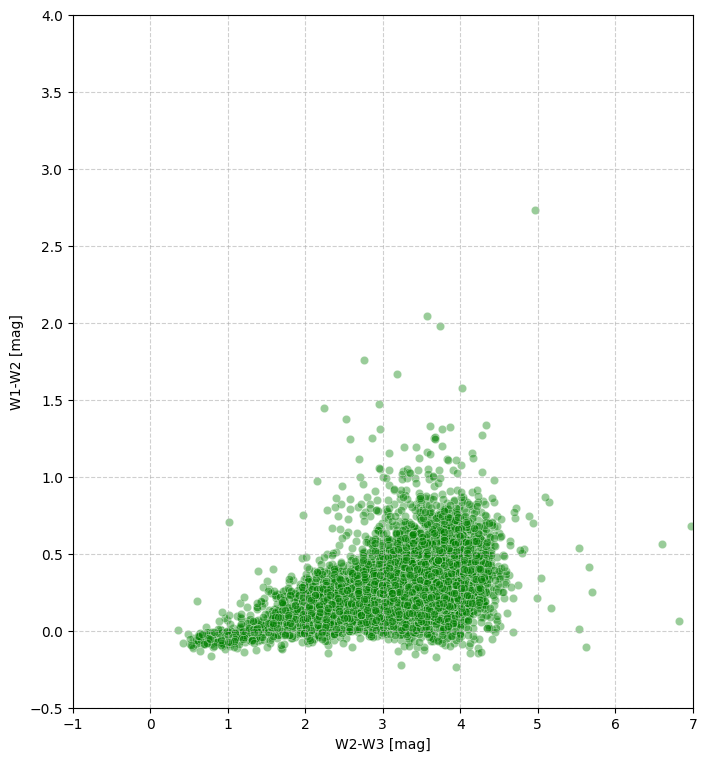

In [ ]:
plt.figure(figsize=(8, 9)) # The shape and x and y limits of this plot were implemented such that it could be overlayed to Figure 12 in Wright et al. (2010).
sns.scatterplot(data=wdf,y='W1-W2 [mag]',x='W2-W3 [mag]',color='green',alpha=0.4)
#plt.legend()
plt.xlim(-1,7)
plt.ylim(-0.5,4)
plt.grid(True,linestyle='--',alpha=0.6)
plt.savefig('wrightccc.png')

In [ ]:
f0_W1 = 309.540
f0_W2 = 171.787 # (Jy)
f0_W3 = 31.674

In [ ]:
# Compute fluxes
wdf['f_3.4'] = f0_W1 * 10 ** (-wdf['w1'] / 2.5)
wdf['f_4.6'] = f0_W2 * 10 ** (-wdf['w2'] / 2.5)
wdf['f_12'] = f0_W3 * 10 ** (-wdf['w3'] / 2.5)
wdf['Y'] = np.log10(wdf['f_4.6']/wdf['f_3.4'])
wdf['X'] = np.log10(wdf['f_12']/wdf['f_4.6'])
x_vals1 = np.linspace(0.03986,0.1566,2)
x_vals2 = np.linspace(0.03986,1.3,2)
x_vals3 = np.linspace(0.1566,1.3,2)
f1 = lambda x: -3.172*x + 0.436
f2 = lambda x: 0.315*x + 0.297
f3 = lambda x: 0.315*x - 0.110

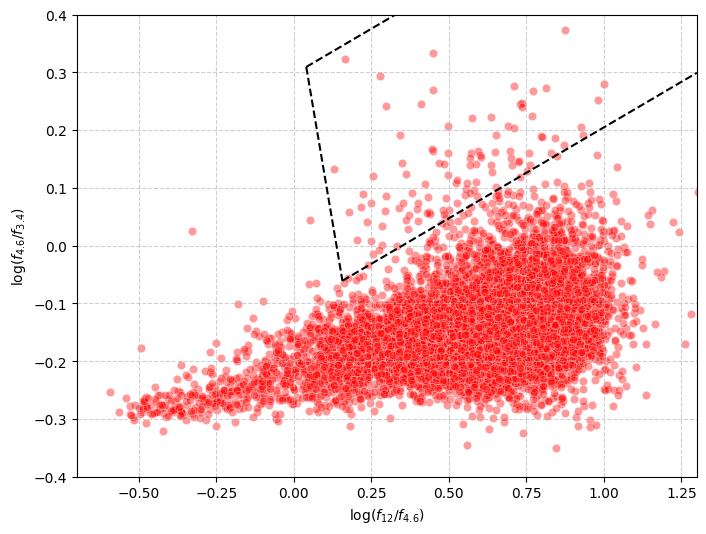

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=wdf,x='X',y='Y', color='red',alpha=0.4)
plt.xlabel(r'$\log(f_{12}/f_{4.6})$')
plt.ylabel(r'$\log(f_{4.6}/f_{3.4})$')
plt.plot(x_vals1,f1(x_vals1),'--',color='black')
plt.plot(x_vals2,f2(x_vals2),'--',color='black')
plt.plot(x_vals3,f3(x_vals3),'--',color='black')
#plt.legend()
plt.xlim(-0.7,1.3)
plt.ylim(-0.4,0.4)
plt.grid(True,linestyle='--',alpha=0.6)

In [ ]:
f1i = lambda y: (0.436-y)/3.172

In [ ]:
wdf['Type'] = 'Unclassified'
for i in range(10000):
    if (wdf['Y'][i] > f3(wdf['X'][i])) and (wdf['Y'][i] < f2(wdf['X'][i])) and (wdf['X'][i] > f1i(wdf['Y'][i])):
        wdf['Type'][i] = 'AGN'

/tmp/ipython-input-1129171652.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  wdf['Type'][i] = 'AGN'
/tmp/ipython-input-1129171652.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the 

In [ ]:
count=0
for i in range(10000):
    if wdf['Type'][i] == 'AGN':
        count += 1

print(f"Number of AGN's in group identified by WISE:                {count} ({round(count/29.43,1)}%)")

Number of AGN's in group identified by WISE:                105 (3.6%)


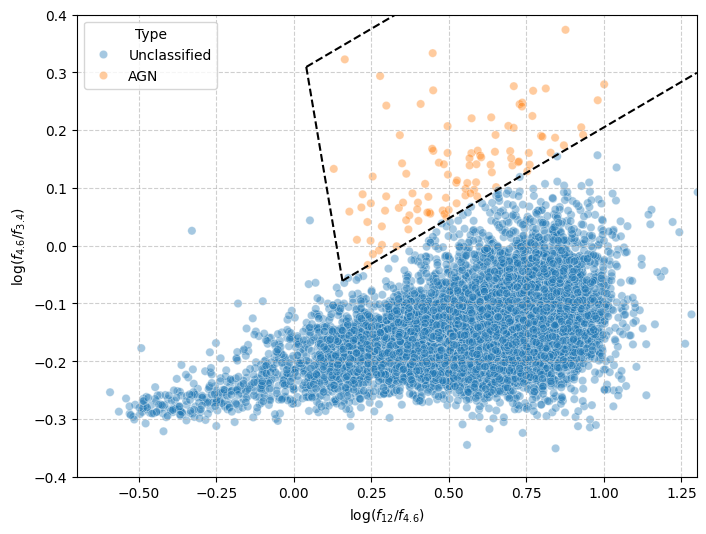

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=wdf,x='X',y='Y', color='red',hue='Type',alpha=0.4)
plt.xlabel(r'$\log(f_{12}/f_{4.6})$')
plt.ylabel(r'$\log(f_{4.6}/f_{3.4})$')
plt.plot(x_vals1,f1(x_vals1),'--',color='black')
plt.plot(x_vals2,f2(x_vals2),'--',color='black')
plt.plot(x_vals3,f3(x_vals3),'--',color='black')
#plt.legend()
plt.xlim(-0.7,1.3)
plt.ylim(-0.4,0.4)
plt.grid(True,linestyle='--',alpha=0.6)
plt.savefig('WISE.png', bbox_inches='tight', pad_inches=0, transparent=True)

In [ ]:
custom_palette = {
    'Unclassified': 'blue',
    'AGN': 'green'
}


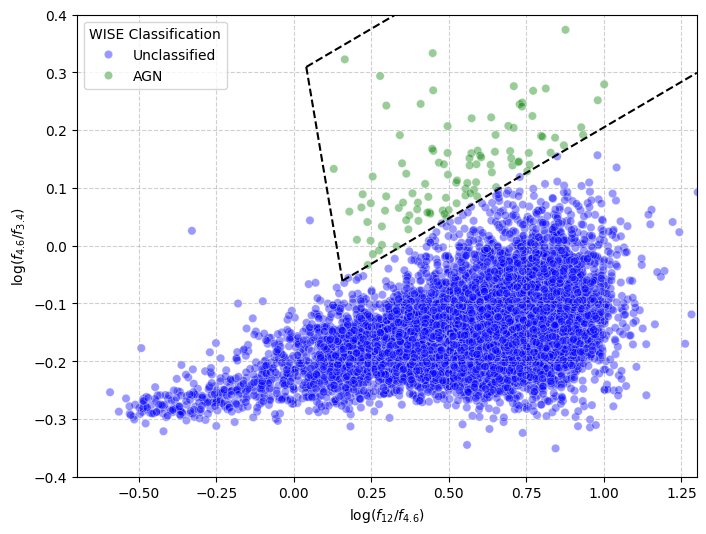

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=wdf,
    x='X',
    y='Y',
    hue='Type',
    palette=custom_palette,
    alpha=0.4
)

plt.xlabel(r'$\log(f_{12}/f_{4.6})$')
plt.ylabel(r'$\log(f_{4.6}/f_{3.4})$')

plt.plot(x_vals1, f1(x_vals1), '--', color='black')
plt.plot(x_vals2, f2(x_vals2), '--', color='black')
plt.plot(x_vals3, f3(x_vals3), '--', color='black')

plt.xlim(-0.7,1.3)
plt.ylim(-0.4,0.4)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='WISE Classification')

plt.savefig('WISE c.png', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()


In [ ]:
wdf['name'] = names

In [ ]:
merged = pd.merge(wdf, data, on='name', suffixes=('WISE', 'SSDS'))
merged

,plateWISE,mjdWISE,fiberidWISE,redshift,subclass,w1,w2,w3,w1flux,w2flux,...,nii_6584_flux,oi_6300_flux,sii_6717_flux,sii_6731_flux,h_alpha_eqw,y_values,x_values,TypeSSDS,y2_values,Type_WHAN
0,421,51821,290,0.114989,NaN,15.026,14.741,10.969,154.78,80.072,...,25.78963,6.269853,30.26996,25.72297,-21.187690,-0.033744,-0.693403,Galaxies,1.326084,Star-Forming
1,420,51871,45,0.057264,STARBURST,14.753,14.583,10.654,198.98,92.645,...,427.15960,66.433190,202.71810,165.03950,-70.000720,0.076788,-0.298900,Composites,1.845103,Seyfert
2,420,51871,17,0.103669,STARFORMING,15.265,15.082,11.240,124.11,58.516,...,72.38217,8.882089,36.02143,19.18493,-11.627980,-0.258367,-0.382941,Galaxies,1.065504,Seyfert
3,420,51871,8,0.082127,STARFORMING,14.827,14.552,10.848,185.87,95.350,...,89.19385,6.441563,46.17053,32.38400,-12.713860,-0.516099,-0.402559,Galaxies,1.104277,Star-Forming
4,403,51871,639,0.119047,NaN,14.876,14.566,11.229,177.66,94.076,...,44.43774,8.424724,20.84057,15.10460,-9.581162,-0.196777,-0.343897,Composites,0.981418,Seyfert
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,666,52149,41,0.006397,STARBURST,13.759,13.676,11.659,497.19,213.600,...,27.85459,7.336809,27.14297,16.21060,-8.610449,-0.236161,-0.489713,Galaxies,0.935026,Star-Forming
9996,666,52149,46,0.085374,NaN,14.445,14.235,11.108,264.30,127.690,...,300.95630,15.138160,71.01506,58.90917,-19.704540,-0.441615,-0.352347,Galaxies,1.294566,Seyfert
9997,666,52149,49,0.048324,STARFORMING,13.467,13.232,9.142,650.32,321.620,...,83.68283,9.108830,41.73671,22.34442,-10.674020,-0.167789,-0.327083,Composites,1.028328,Seyfert
9998,666,52149,57,0.086001,STARFORMING,15.115,14.867,11.746,142.56,71.348,...,12.39399,2.345244,15.20910,10.29937,-18.463530,0.089036,-0.732628,Galaxies,1.266315,Star-Forming


In [ ]:
count=0
for i in range(10000):
    if (merged['TypeSSDS'][i] == merged['TypeWISE'][i]) or (merged['Type_WHAN'][i]=='Seyfert' and merged['TypeWISE'][i] =='AGN'):
        count+=1
print(f"Number of AGN's objects defined as AGN by SDSS and WISE:                {count} ")

Number of AGN's objects defined as AGN by SDSS and WISE:                46 
